#**KNN**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

In [3]:
digits = load_digits()

In [4]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [5]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [6]:
digits.feature_names

['pixel_0_0',
 'pixel_0_1',
 'pixel_0_2',
 'pixel_0_3',
 'pixel_0_4',
 'pixel_0_5',
 'pixel_0_6',
 'pixel_0_7',
 'pixel_1_0',
 'pixel_1_1',
 'pixel_1_2',
 'pixel_1_3',
 'pixel_1_4',
 'pixel_1_5',
 'pixel_1_6',
 'pixel_1_7',
 'pixel_2_0',
 'pixel_2_1',
 'pixel_2_2',
 'pixel_2_3',
 'pixel_2_4',
 'pixel_2_5',
 'pixel_2_6',
 'pixel_2_7',
 'pixel_3_0',
 'pixel_3_1',
 'pixel_3_2',
 'pixel_3_3',
 'pixel_3_4',
 'pixel_3_5',
 'pixel_3_6',
 'pixel_3_7',
 'pixel_4_0',
 'pixel_4_1',
 'pixel_4_2',
 'pixel_4_3',
 'pixel_4_4',
 'pixel_4_5',
 'pixel_4_6',
 'pixel_4_7',
 'pixel_5_0',
 'pixel_5_1',
 'pixel_5_2',
 'pixel_5_3',
 'pixel_5_4',
 'pixel_5_5',
 'pixel_5_6',
 'pixel_5_7',
 'pixel_6_0',
 'pixel_6_1',
 'pixel_6_2',
 'pixel_6_3',
 'pixel_6_4',
 'pixel_6_5',
 'pixel_6_6',
 'pixel_6_7',
 'pixel_7_0',
 'pixel_7_1',
 'pixel_7_2',
 'pixel_7_3',
 'pixel_7_4',
 'pixel_7_5',
 'pixel_7_6',
 'pixel_7_7']

In [7]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

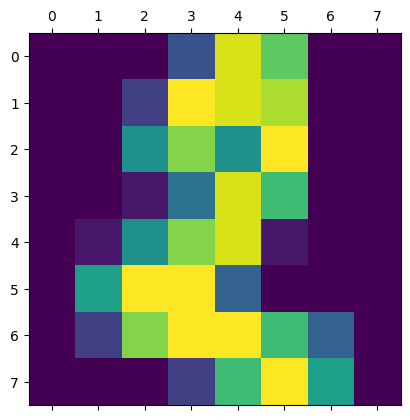

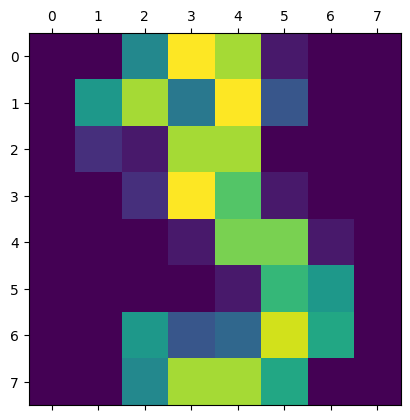

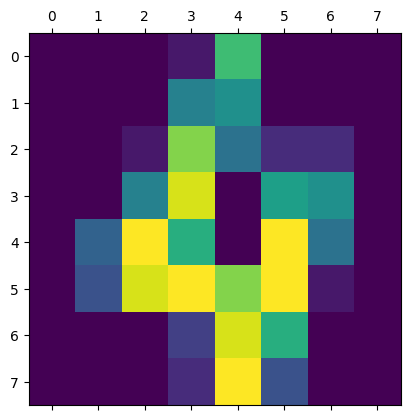

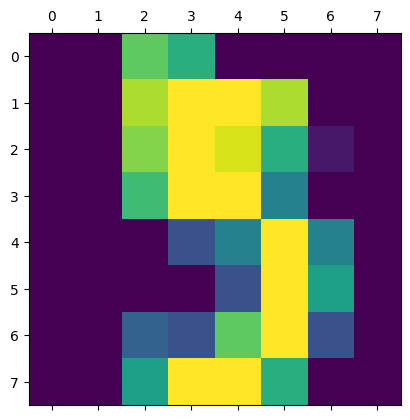

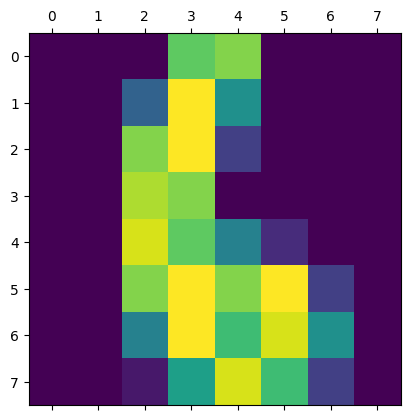

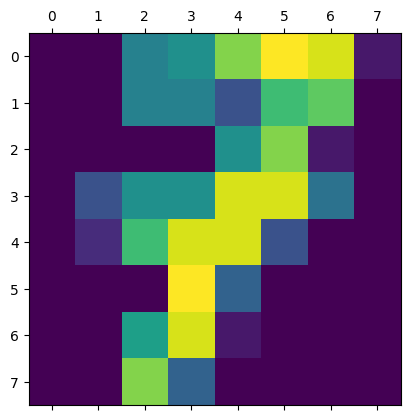

In [8]:
for i in range(2,8):
  plt.matshow(digits.images[i])

In [9]:
x = digits.data
y = digits.target

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.8)

In [11]:
len(x_train)

359

In [12]:
len(x_test)

1438

In [13]:
knn = KNeighborsClassifier()

In [14]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [24]:
y_pred = knn.predict(x_test)
y_pred

array([2, 8, 0, ..., 9, 9, 4])

In [25]:
knn.score(x_test,y_test)

0.8949930458970793

**Different K Values**

In [26]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train,y_train)
knn.score(x_test,y_test)

0.9645340751043116

In [27]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train,y_train)
knn.score(x_test,y_test)

0.9450625869262865

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
knn.score(x_test,y_test)

0.9575799721835884

In [29]:
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
knn.score(x_test,y_test)

0.911682892906815

In [30]:
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(x_train,y_train)
knn.score(x_test,y_test)

0.8949930458970793

**Confusion Matrix**

In [38]:
from sklearn.metrics import confusion_matrix,classification_report

In [39]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[137,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 124,   0,   0,   0,   0,   0,   0,   0,  16],
       [  1,   8, 127,   2,   0,   0,   0,   1,   8,   0],
       [  0,   0,   2, 123,   0,   2,   0,   3,   0,  20],
       [  1,   6,   0,   0, 138,   0,   0,   5,   3,   0],
       [  0,   0,   0,   0,   1, 129,   1,   0,   0,  15],
       [  1,   2,   0,   0,   0,   0, 143,   0,   0,   0],
       [  0,   5,   0,   0,   0,   0,   0, 137,   4,   1],
       [  0,  14,   0,   2,   0,   1,   1,   1, 106,  13],
       [  1,   0,   0,   1,   0,   3,   0,   5,   1, 123]])

In [40]:
import seaborn as sn

Text(50.722222222222214, 0.5, 'Truth')

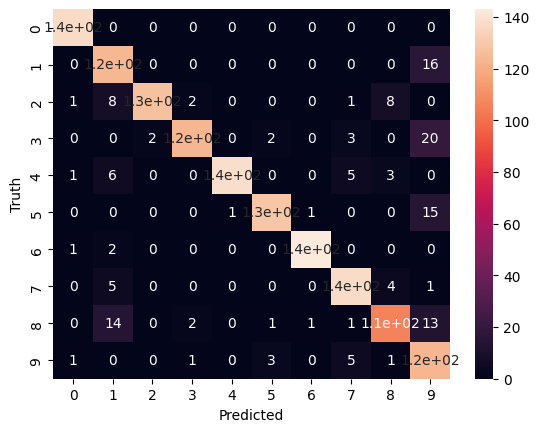

In [41]:
sn.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")

**Classsification Report**

In [43]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       137
           1       0.78      0.89      0.83       140
           2       0.98      0.86      0.92       147
           3       0.96      0.82      0.88       150
           4       0.99      0.90      0.95       153
           5       0.96      0.88      0.92       146
           6       0.99      0.98      0.98       146
           7       0.90      0.93      0.92       147
           8       0.87      0.77      0.82       138
           9       0.65      0.92      0.76       134

    accuracy                           0.89      1438
   macro avg       0.91      0.90      0.90      1438
weighted avg       0.91      0.89      0.90      1438

